# 🏀 NBA Player Scoring Prediction — Portfolio Project 1
### INFO 4604 | Linear Regression with Feature Engineering

---

**Goal:** Can we predict an NBA player's points per game from their shooting and playing-time stats?

Every coach and analyst in professional basketball is trying to answer versions of this question. This project builds a **Multiple Linear Regression** model using real NBA data going back to 1947, with a full **Feature Engineering** pipeline before the model is trained.

**Dataset:** [NBA Stats 1947–Present](https://www.kaggle.com/datasets/sumitrodatta/nba-aba-baa-stats) via Kaggle — scraped from Basketball Reference, covering every player-season in NBA/ABA/BAA history.

**Target (y):** `pts_per_game` — average points scored per game  
**Features (X):** Minutes played, shooting percentages, assists, rebounds, steals, blocks, turnovers, position

---

## Step 0 — Download Dataset & Imports

In [ ]:
import kagglehub
# Download latest version
path = kagglehub.dataset_download("sumitrodatta/nba-aba-baa-stats")
print("Path to dataset files:", path)

100%|██████████| 10.6M/10.6M [00:00<00:00, 34.9MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/sumitrodatta/nba-aba-baa-stats/versions/54


In [ ]:
import os
# See what CSV files are available in the downloaded folder
for f in os.listdir(path):
    print(f)

Per 100 Poss.csv
Player Career Info.csv
Player Shooting.csv
Player Season Info.csv
Team Totals.csv
Opponent Totals.csv
Advanced.csv
Team Abbrev.csv
Team Stats Per Game.csv
Player Award Shares.csv
Opponent Stats Per Game.csv
Player Play By Play.csv
End of Season Teams.csv
Team Summaries.csv
Per 36 Minutes.csv
Player Per Game.csv
Player Totals.csv
Team Stats Per 100 Poss.csv
All-Star Selections.csv
End of Season Teams (Voting).csv
Draft Pick History.csv
Opponent Stats Per 100 Poss.csv


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

In [ ]:
# Load the Per Game stats CSV — this is the main file we need
df = pd.read_csv(f'{path}/Player Per Game.csv')
df.head(10)

,season,lg,player,player_id,age,team,pos,g,gs,mp_per_game,...,ft_percent,orb_per_game,drb_per_game,trb_per_game,ast_per_game,stl_per_game,blk_per_game,tov_per_game,pf_per_game,pts_per_game
0,2026,NBA,Precious Achiuwa,achiupr01,26.0,SAC,C,53,37.0,21.2,...,0.532,2.1,3.7,5.8,1.2,0.9,0.6,0.7,1.7,8.1
1,2026,NBA,Steven Adams,adamsst01,32.0,HOU,C,32,11.0,22.8,...,0.580,4.5,4.1,8.6,1.5,0.7,0.6,1.1,1.7,5.8
2,2026,NBA,Bam Adebayo,adebaba01,28.0,MIA,C,53,53.0,31.4,...,0.765,2.1,7.8,9.9,2.8,1.0,0.7,1.8,1.6,18.6
3,2026,NBA,Ochai Agbaji,agbajoc01,25.0,2TM,SG,49,13.0,15.5,...,0.839,0.8,1.5,2.3,0.8,0.4,0.3,0.4,1.6,4.5
4,2026,NBA,Ochai Agbaji,agbajoc01,25.0,TOR,SG,42,13.0,15.5,...,0.862,0.8,1.5,2.3,0.7,0.4,0.3,0.5,1.8,4.3
5,2026,NBA,Ochai Agbaji,agbajoc01,25.0,BRK,SG,7,0.0,15.7,...,0.500,0.7,1.7,2.4,1.4,0.1,0.4,0.4,0.6,5.7
6,2026,NBA,Santi Aldama,aldamsa01,25.0,MEM,PF,43,11.0,27.9,...,0.667,1.6,5.1,6.7,2.9,0.9,0.7,1.3,1.6,14.0
7,2026,NBA,Nickeil Alexander-Walker,alexani01,27.0,ATL,SG,58,51.0,33.2,...,0.888,0.6,3.0,3.6,3.8,1.2,0.6,2.1,2.1,19.8
8,2026,NBA,Trey Alexander,alexatr01,22.0,NOP,SG,5,0.0,8.4,...,NaN,0.0,0.8,0.8,1.0,0.2,0.2,0.2,0.8,2.8
9,2026,NBA,Grayson Allen,allengr01,30.0,PHO,SG,38,26.0,30.2,...,0.861,0.7,2.4,3.1,3.9,1.4,0.3,1.7,2.2,17.5


In [ ]:
# High-level overview
print(f'Shape: {df.shape}')
print()
df.info()

Shape: (33278, 32)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33278 entries, 0 to 33277
Data columns (total 32 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   season         33278 non-null  int64  
 1   lg             33278 non-null  object 
 2   player         33278 non-null  object 
 3   player_id      33278 non-null  object 
 4   age            33258 non-null  float64
 5   team           33278 non-null  object 
 6   pos            32081 non-null  object 
 7   g              33278 non-null  int64  
 8   gs             25100 non-null  float64
 9   mp_per_game    32195 non-null  float64
 10  fg_per_game    33278 non-null  float64
 11  fga_per_game   33278 non-null  float64
 12  fg_percent     33112 non-null  float64
 13  x3p_per_game   26926 non-null  float64
 14  x3pa_per_game  26925 non-null  float64
 15  x3p_percent    22655 non-null  float64
 16  x2p_per_game   26926 non-null  float64
 17  x2pa_per_game  26926 non-null 

In [ ]:
# Summary statistics
df.describe()

,season,age,g,gs,mp_per_game,fg_per_game,fga_per_game,fg_percent,x3p_per_game,x3pa_per_game,...,ft_percent,orb_per_game,drb_per_game,trb_per_game,ast_per_game,stl_per_game,blk_per_game,tov_per_game,pf_per_game,pts_per_game
count,33278.000000,33258.000000,33278.000000,25100.000000,32195.000000,33278.000000,33278.000000,33112.000000,26926.000000,26925.000000,...,31894.000000,28632.000000,28632.000000,32384.000000,33278.000000,27676.000000,27678.000000,27642.000000,33277.000000,33278.000000
mean,1996.335988,26.466895,48.294519,22.396255,20.125728,3.169322,7.141709,0.430757,0.491083,1.428409,...,0.723095,1.035708,2.530693,3.719244,1.878914,0.662542,0.402688,1.248253,1.975809,8.349053
std,20.910643,3.861239,26.585486,27.847340,10.211540,2.302377,4.825255,0.102310,0.678686,1.798461,...,0.144118,0.886210,1.854071,2.805783,1.775672,0.476581,0.491331,0.848501,0.917649,6.114628
min,1947.000000,18.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1980.000000,24.000000,24.000000,0.000000,11.700000,1.400000,3.400000,0.391000,0.000000,0.000000,...,0.660000,0.400000,1.200000,1.700000,0.600000,0.300000,0.100000,0.600000,1.300000,3.600000
50%,1999.000000,26.000000,53.000000,7.000000,19.400000,2.600000,6.000000,0.438000,0.200000,0.600000,...,0.747000,0.800000,2.100000,3.000000,1.300000,0.600000,0.300000,1.100000,2.000000,6.800000
75%,2014.000000,29.000000,73.000000,42.000000,28.500000,4.500000,10.000000,0.481000,0.800000,2.300000,...,0.813000,1.400000,3.400000,4.900000,2.500000,0.900000,0.500000,1.700000,2.600000,11.700000
max,2026.000000,46.000000,90.000000,84.000000,48.500000,20.000000,39.500000,1.000000,5.300000,13.200000,...,1.000000,7.200000,13.700000,27.200000,14.500000,4.100000,6.000000,5.700000,6.000000,50.400000


In [ ]:
# Filter to modern NBA era only (2000 onwards) and NBA league only (not ABA/BAA)
# This keeps the data relevant and consistent — older eras had very different playing styles
df = df[(df['season'] >= 2000) & (df['lg'] == 'NBA')]
print(f'Rows after filtering to NBA 2000+: {len(df)}')

Rows after filtering to NBA 2000+: 16565


---
## Step 1 — Feature Engineering

1. **Feature Selection** — pick the columns that actually matter
2. **Missing Values** — handle NaN rows
3. **Correlated Features** — remove redundant inputs
4. **Outliers** — spot and remove extreme values
5. **Normalization + One-Hot Encoding** — scale numeric features, convert categoricals



### 1a. Feature Selection

In [ ]:
# Select the columns relevant to our prediction task
# We want to predict pts_per_game (y) from performance and playing-time stats (X)

cols_to_keep = [
    'pts_per_game',   # TARGET (y)
    'mp_per_game',    # minutes per game
    'ast_per_game',   # assists per game
    'trb_per_game',   # total rebounds per game
    'stl_per_game',   # steals per game
    'blk_per_game',   # blocks per game
    'tov_per_game',   # turnovers per game
    'fga_per_game',   # field goal attempts per game
    'fg_percent',     # field goal percentage
    'x3p_percent',    # 3-point percentage
    'ft_percent',     # free throw percentage
    'pos'             # position (categorical)
]

df_clean = df[cols_to_keep].copy()
df_clean.head()

,pts_per_game,mp_per_game,ast_per_game,trb_per_game,stl_per_game,blk_per_game,tov_per_game,fga_per_game,fg_percent,x3p_percent,ft_percent,pos
0,8.1,21.2,1.2,5.8,0.9,0.6,0.7,6.7,0.517,0.328,0.532,C
1,5.8,22.8,1.5,8.6,0.7,0.6,1.1,4.3,0.504,NaN,0.580,C
2,18.6,31.4,2.8,9.9,1.0,0.7,1.8,14.8,0.449,0.344,0.765,C
3,4.5,15.5,0.8,2.3,0.4,0.3,0.4,4.1,0.426,0.267,0.839,SG
4,4.3,15.5,0.7,2.3,0.4,0.3,0.5,4.0,0.424,0.185,0.862,SG


### 1b. Missing Values

In [ ]:
# Check for missing values per column
print('Missing values per column:')
print(df_clean.isnull().sum())

Missing values per column:
pts_per_game       0
mp_per_game        0
ast_per_game       0
trb_per_game       0
stl_per_game       0
blk_per_game       0
tov_per_game       0
fga_per_game       0
fg_percent       102
x3p_percent     2171
ft_percent       891
pos                1
dtype: int64


In [ ]:
# Drop rows with any missing values
# (Most NaN values here are shooting % for players who never attempted those shots)
df_clean = df_clean.dropna()
print(f'Rows remaining after dropping NaN: {len(df_clean)}')

Rows remaining after dropping NaN: 13872


In [ ]:
# Also filter to players who averaged at least 10 minutes per game
# Players with very low minutes have unreliable per-game stats (small sample size)
df_clean = df_clean[df_clean['mp_per_game'] >= 10]
print(f'Rows remaining after filtering for 10+ min/game: {len(df_clean)}')

Rows remaining after filtering for 10+ min/game: 12030


### 1c. One-Hot Encode the Position Column

The `pos` column is categorical text (PG, SG, SF, PF, C). sklearn needs everything numeric, so we use `pd.get_dummies()` to convert it.

In [ ]:
# Check what positions exist in the data
print(df_clean['pos'].unique())

['C' 'SG' 'PF' 'PG' 'SF']


In [ ]:
# Some players have multi-position labels like 'PG-SG' — simplify to first position listed
df_clean['pos'] = df_clean['pos'].str.split('-').str[0]
print(df_clean['pos'].unique())

['C' 'SG' 'PF' 'PG' 'SF']


In [ ]:
# One-hot encode the 'pos' column using pd.get_dummies()
df_clean = pd.get_dummies(df_clean, columns=['pos'])
df_clean.head()

,pts_per_game,mp_per_game,ast_per_game,trb_per_game,stl_per_game,blk_per_game,tov_per_game,fga_per_game,fg_percent,x3p_percent,ft_percent,pos_C,pos_PF,pos_PG,pos_SF,pos_SG
0,8.1,21.2,1.2,5.8,0.9,0.6,0.7,6.7,0.517,0.328,0.532,True,False,False,False,False
2,18.6,31.4,2.8,9.9,1.0,0.7,1.8,14.8,0.449,0.344,0.765,True,False,False,False,False
3,4.5,15.5,0.8,2.3,0.4,0.3,0.4,4.1,0.426,0.267,0.839,False,False,False,False,True
4,4.3,15.5,0.7,2.3,0.4,0.3,0.5,4.0,0.424,0.185,0.862,False,False,False,False,True
5,5.7,15.7,1.4,2.4,0.1,0.4,0.4,4.6,0.438,0.524,0.500,False,False,False,False,True


### 1d. Remove Highly Correlated Features

Highly correlated features carry duplicate information and can destabilize the model coefficients. We flag any correlation above 0.85.

In [ ]:
# Numeric feature columns (excluding target and one-hot cols)
numeric_features = ['mp_per_game', 'ast_per_game', 'trb_per_game', 'stl_per_game',
                    'blk_per_game', 'tov_per_game', 'fga_per_game', 'fg_percent',
                    'x3p_percent', 'ft_percent']

# Print correlation matrix, highlight entries > 0.85 in red
df_clean[numeric_features].corr().style.applymap(lambda x: 'color: red' if abs(x) > 0.85 and x != 1.0 else '')

/tmp/ipykernel_346/2785827544.py:7: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  df_clean[numeric_features].corr().style.applymap(lambda x: 'color: red' if abs(x) > 0.85 and x != 1.0 else '')


,mp_per_game,ast_per_game,trb_per_game,stl_per_game,blk_per_game,tov_per_game,fga_per_game,fg_percent,x3p_percent,ft_percent
mp_per_game,1.000000,0.618994,0.585449,0.668801,0.307954,0.757928,0.871964,0.190227,0.129064,0.207957
ast_per_game,0.618994,1.000000,0.150635,0.605402,-0.057375,0.772207,0.616933,-0.010833,0.177219,0.225632
trb_per_game,0.585449,0.150635,1.000000,0.306708,0.676579,0.460664,0.501584,0.475082,-0.196536,-0.114810
stl_per_game,0.668801,0.605402,0.306708,1.000000,0.133757,0.600673,0.578532,0.060660,0.109845,0.105187
blk_per_game,0.307954,-0.057375,0.676579,0.133757,1.000000,0.211257,0.232725,0.414823,-0.229602,-0.182275
tov_per_game,0.757928,0.772207,0.460664,0.600673,0.211257,1.000000,0.804256,0.125483,0.052075,0.153374
fga_per_game,0.871964,0.616933,0.501584,0.578532,0.232725,0.804256,1.000000,0.128405,0.164820,0.264985
fg_percent,0.190227,-0.010833,0.475082,0.060660,0.414823,0.125483,0.128405,1.000000,-0.072816,-0.124807
x3p_percent,0.129064,0.177219,-0.196536,0.109845,-0.229602,0.052075,0.164820,-0.072816,1.000000,0.273857
ft_percent,0.207957,0.225632,-0.114810,0.105187,-0.182275,0.153374,0.264985,-0.124807,0.273857,1.000000


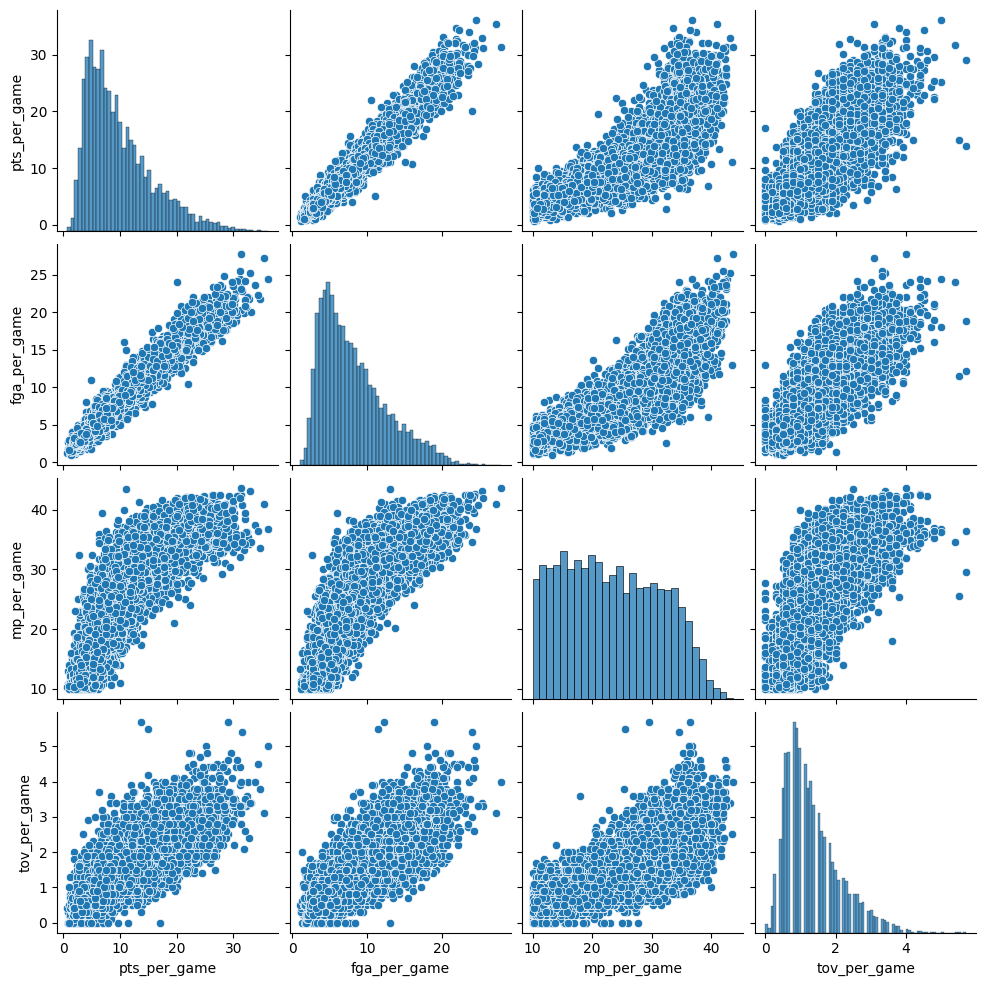

In [ ]:
# Visualise the most likely correlated pairs
sns.pairplot(df_clean[['pts_per_game', 'fga_per_game', 'mp_per_game', 'tov_per_game']]);

In [ ]:
# fga_per_game (shot attempts) is very highly correlated with pts_per_game
# and tov_per_game correlates strongly with both fga and pts (high-usage players do all three)
# We KEEP fga_per_game as a feature — it's a legitimate predictor
# We DROP tov_per_game to reduce redundancy with fga_per_game

df_clean = df_clean.drop(columns=['tov_per_game'])
numeric_features.remove('tov_per_game')
print('Updated feature list:', numeric_features)

Updated feature list: ['mp_per_game', 'ast_per_game', 'trb_per_game', 'stl_per_game', 'blk_per_game', 'fga_per_game', 'fg_percent', 'x3p_percent', 'ft_percent']


### 1e. Detect & Remove Outliers

A few extreme values can heavily distort the regression line. We use histograms to visually inspect each feature.

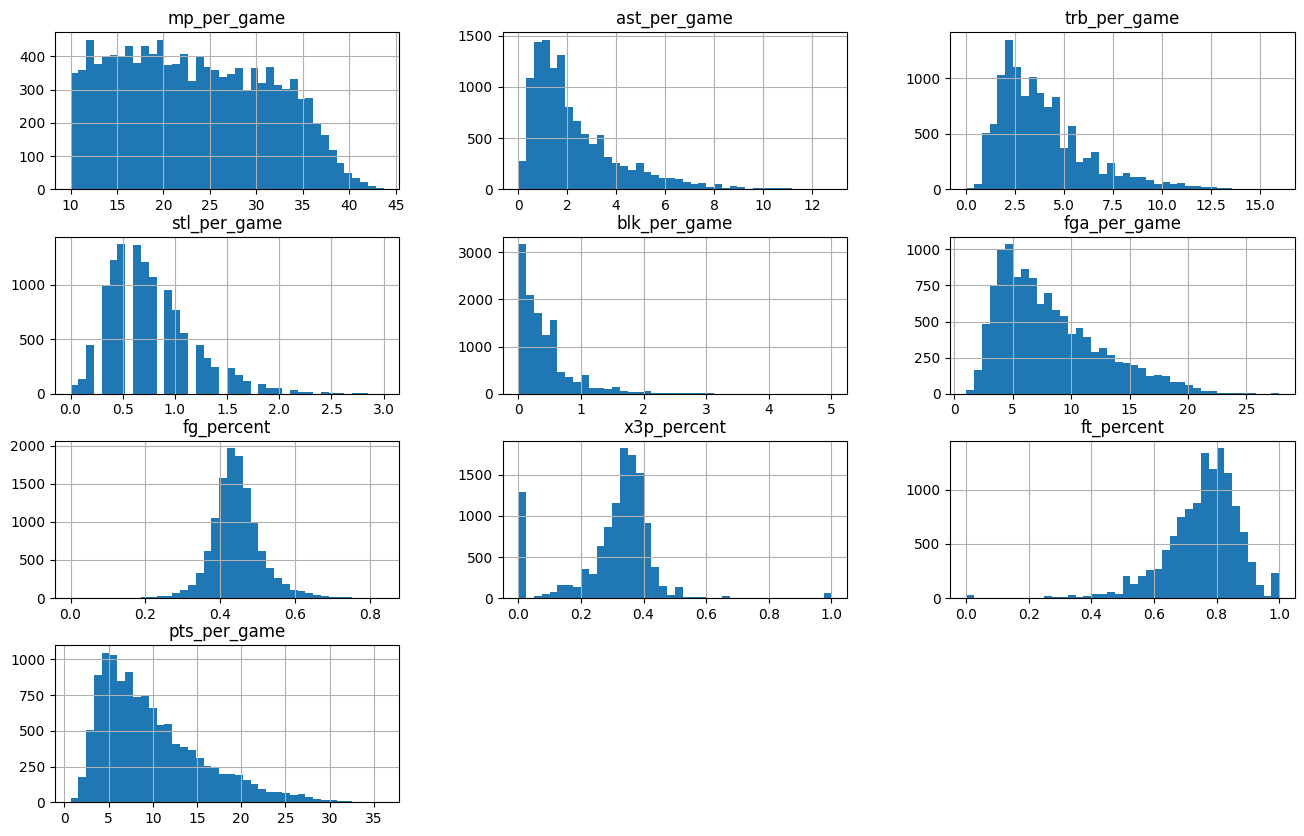

In [ ]:
# Histogram of each numeric feature
df_clean[numeric_features + ['pts_per_game']].hist(bins=40, figsize=(16, 10));

In [ ]:
# Define outlier thresholds based on what we see in the histograms
conditions = [
    df_clean['pts_per_game'] > 40,    # only 1-2 all-time seasons ever hit this
    df_clean['mp_per_game'] > 42,     # more than 42 min/game is extreme
    df_clean['fga_per_game'] > 30,    # 30+ attempts per game is extreme
]

# Combine conditions using logical OR
combined_condition = conditions[0]
for condition in conditions[1:]:
    combined_condition |= condition

# Remove outlier rows
df_clean = df_clean[~combined_condition]
print(f'Rows remaining after removing outliers: {len(df_clean)}')

Rows remaining after removing outliers: 12016


### 1f. Normalize the Numeric Features

Minutes per game (~25) and shooting percentages (~0.45) are on very different scales. `MinMaxScaler` rescales everything to 0–1 so no feature dominates purely due to its units.

In [ ]:
from sklearn.preprocessing import MinMaxScaler

# Separate X (features) and y (target)
pos_cols = [c for c in df_clean.columns if c.startswith('pos_')]
feature_cols = numeric_features + pos_cols

y = df_clean[['pts_per_game']]

# Normalize the numeric features
scaler = MinMaxScaler()
X_numeric_scaled = scaler.fit_transform(df_clean[numeric_features])
X_numeric_scaled_df = pd.DataFrame(X_numeric_scaled, columns=numeric_features, index=df_clean.index)

# Combine normalized numerics with the one-hot encoded position columns
X = pd.concat([X_numeric_scaled_df, df_clean[pos_cols]], axis=1)

print('Feature Engineering complete!')
print(f'X shape: {X.shape}  |  y shape: {y.shape}')
X.head()

Feature Engineering complete!
X shape: (12016, 14)  |  y shape: (12016, 1)


,mp_per_game,ast_per_game,trb_per_game,stl_per_game,blk_per_game,fga_per_game,fg_percent,x3p_percent,ft_percent,pos_C,pos_PF,pos_PG,pos_SF,pos_SG
0,0.350000,0.093750,0.36250,0.300000,0.12,0.217557,0.618421,0.328,0.532,True,False,False,False,False
2,0.668750,0.218750,0.61875,0.333333,0.14,0.526718,0.537081,0.344,0.765,True,False,False,False,False
3,0.171875,0.062500,0.14375,0.133333,0.06,0.118321,0.509569,0.267,0.839,False,False,False,False,True
4,0.171875,0.054688,0.14375,0.133333,0.06,0.114504,0.507177,0.185,0.862,False,False,False,False,True
5,0.178125,0.109375,0.15000,0.033333,0.08,0.137405,0.523923,0.524,0.500,False,False,False,False,True


---
## Step 2 — Multiple Linear Regression Model

With the data cleaned and prepared, we can now build the model using `sklearn.linear_model.LinearRegression` — the same approach from class, scaled up to multiple input features.

In [ ]:
# Create an empty linear regression model
pts_model = sklearn.linear_model.LinearRegression()

In [ ]:
# Train the model on the full cleaned dataset
pts_model.fit(X, y)

LinearRegression()

In [ ]:
# View the model coefficients (gradient for each feature)
m = pts_model.coef_
b = pts_model.intercept_
print(f'Intercept (b): {b[0]:.4f}')
print()

coef_df = pd.DataFrame({'Feature': X.columns, 'Coefficient': pts_model.coef_[0]})
coef_df = coef_df.sort_values('Coefficient', ascending=False)
coef_df

Intercept (b): -6.3565



,Feature,Coefficient
5,fga_per_game,32.693168
6,fg_percent,9.870609
8,ft_percent,2.096586
1,ast_per_game,1.673462
2,trb_per_game,1.363461
7,x3p_percent,0.961089
4,blk_per_game,0.832368
12,pos_SF,0.153109
13,pos_SG,0.088484
10,pos_PF,-0.008014


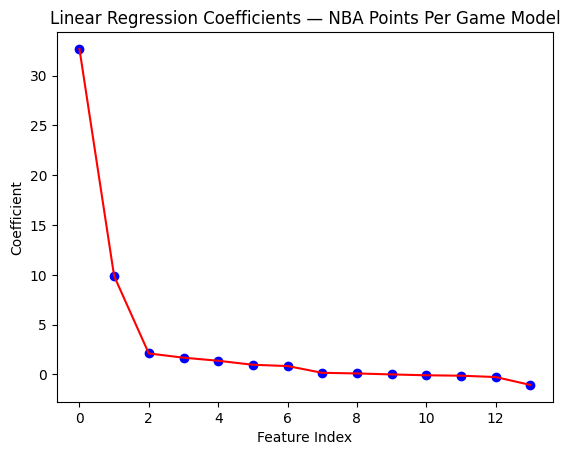

In [31]:
coef_df = pd.DataFrame({'Feature': X.columns, 'Coefficient': pts_model.coef_[0]})
coef_df = coef_df.sort_values('Coefficient', ascending=False)

plt.scatter(range(len(coef_df)), coef_df['Coefficient'], color='blue')
plt.plot(range(len(coef_df)), coef_df['Coefficient'], color='red')
plt.title('Linear Regression Coefficients — NBA Points Per Game Model')
plt.xlabel('Feature Index')
plt.ylabel('Coefficient')
plt.show()

---
## Step 3 —Measure the Model (R-Squared)


In [ ]:
# Calculate R-squared
r2 = pts_model.score(X, y)
print(f'R-Squared: {r2:.4f}')

R-Squared: 0.9742


In [ ]:
# Generate predictions
y_pred = pts_model.predict(X)

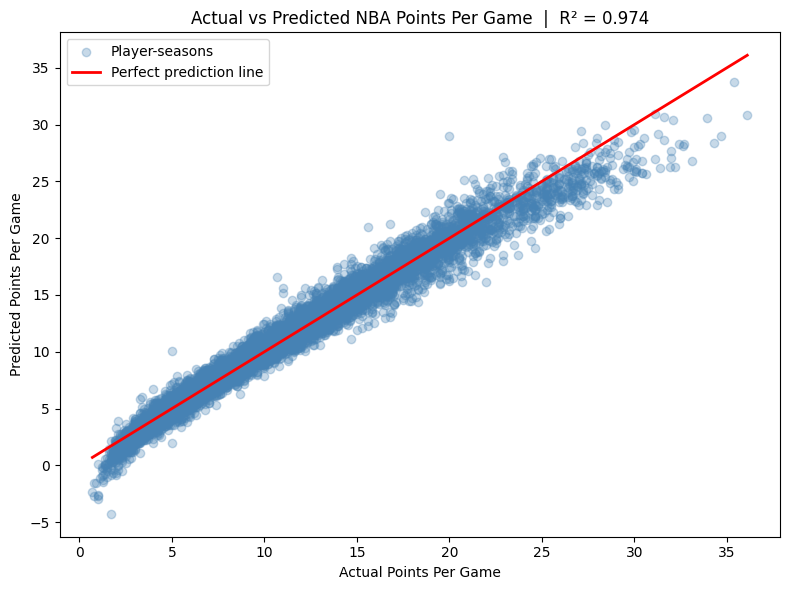

In [ ]:
# Plot: Actual pts_per_game vs Predicted pts_per_game
plt.figure(figsize=(8, 6))
plt.scatter(y, y_pred, color='steelblue', alpha=0.3, label='Player-seasons')
plt.plot([y.min(), y.max()], [y.min(), y.max()], color='red', linewidth=2, label='Perfect prediction line')
plt.xlabel('Actual Points Per Game')
plt.ylabel('Predicted Points Per Game')
plt.title(f'Actual vs Predicted NBA Points Per Game  |  R² = {r2:.3f}')
plt.legend()
plt.tight_layout()
plt.show()

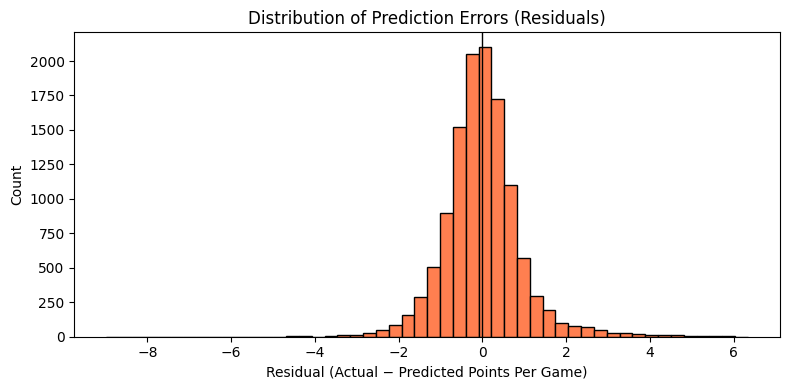

Mean residual: -0.0000  (should be close to 0)


In [ ]:
# Residual distribution — ideally centred at 0
residuals = y.values.flatten() - y_pred.flatten()

plt.figure(figsize=(8, 4))
plt.hist(residuals, bins=50, color='coral', edgecolor='black')
plt.axvline(0, color='black', linewidth=1)
plt.xlabel('Residual (Actual − Predicted Points Per Game)')
plt.ylabel('Count')
plt.title('Distribution of Prediction Errors (Residuals)')
plt.tight_layout()
plt.show()

print(f'Mean residual: {residuals.mean():.4f}  (should be close to 0)')

---
##Step 4 — Make a Prediction

Let's use the trained model to predict the points per game for a hypothetical player.

In [ ]:
# Predict for a hypothetical player:
# 34 mp/g, 6 ast/g, 5 reb/g, 1.5 stl/g, 0.5 blk/g, 16 fga/g, 47% FG, 37% 3P, 85% FT, plays SG

hypothetical_numeric = pd.DataFrame({
    'mp_per_game': [34],
    'ast_per_game': [6],
    'trb_per_game': [5],
    'stl_per_game': [1.5],
    'blk_per_game': [0.5],
    'fga_per_game': [16],
    'fg_percent': [0.47],
    'x3p_percent': [0.37],
    'ft_percent': [0.85]
})

# Apply the SAME scaler we used during training
hypothetical_scaled = scaler.transform(hypothetical_numeric)
hypothetical_scaled_df = pd.DataFrame(hypothetical_scaled, columns=numeric_features)

# Add one-hot encoded position columns (this player is SG)
for col in pos_cols:
    hypothetical_scaled_df[col] = 1 if col == 'pos_SG' else 0

# Make prediction
predicted_pts = pts_model.predict(hypothetical_scaled_df)
print(f'Predicted points per game: {predicted_pts[0][0]:.1f} PPG')

Predicted points per game: 20.5 PPG


---
## ✅ Summary

| Step | What we did |
|------|-------------|
| Dataset | NBA Per Game stats 2000–present (kagglehub download) |
| Feature Selection | Chose 10 meaningful stats + player position |
| Missing Values | Dropped NaN rows; filtered to 10+ min/game |
| One-Hot Encoding | Converted `pos` to numeric columns with `pd.get_dummies()` |
| Correlated Features | Removed `tov_per_game` (highly correlated with `fga_per_game`) |
| Outliers | Removed extreme outliers using histogram-informed thresholds |
| Normalization | Applied `MinMaxScaler` to bring all numeric features to 0–1 range |
| Model | `sklearn.linear_model.LinearRegression` |
| Measurement | R-Squared, Actual vs Predicted scatter plot, Residual distribution |

**Key insight:** `fga_per_game` (shot attempts) has the strongest positive coefficient — the model confirms that shot volume is the dominant predictor of scoring, followed by minutes played. Shooting efficiency (FG%) matters too, but players who take more shots simply score more points on average.

---
*Portfolio Project 1 | INFO 4604*